# Lab 7: t-Distributed Stochastic Neighbor Embedding (t-SNE)
**CS2227: Artificial Intelligence and Machine Learning**  

---

## Conceptual Overview

### Why not just PCA?
PCA is **strictly linear**. It projects data downward like a shadow. Imagine a rolled-up yoga mat (a Swiss Roll) — PCA crushes the underlying structure rather than unrolling it.

### t-SNE
t-SNE is a **manifold learning technique** used for mathematically "unrolling the mat." It:

1. Converts **Euclidean distances** between data points into **conditional probabilities**
2. Minimizes the **Kullback-Leibler (KL) divergence** between the joint probabilities of the low-dimensional embedding and the high-dimensional data
3. Thereby **preserves local neighborhoods** in the projection

> ⚠️ **Important:** t-SNE does **not** have a `transform()` method for new data — only `fit_transform()` for the current dataset. It is also computationally expensive.


## Implementation: t-SNE on the Digits Dataset

Original shape: (1797, 64)
t-SNE reduced shape: (1797, 2)


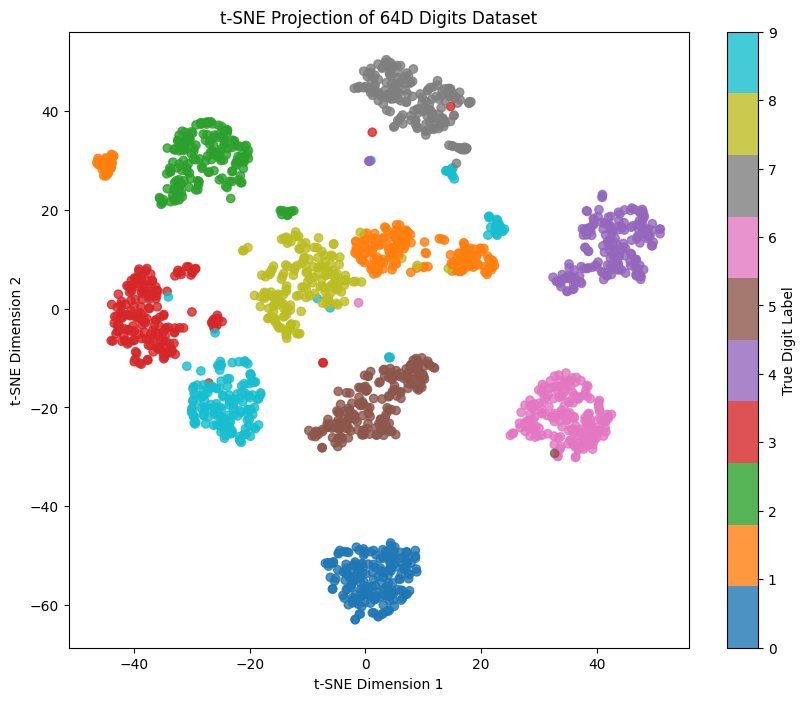

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

# Load a high-dimensional dataset (8x8 pixel images = 64 dimensions)
digits = load_digits()
X = digits.data
y = digits.target

# 1. Initialize t-SNE
# We reduce 64 dimensions down to 2 for visualization
tsne = TSNE(n_components=2, perplexity=30.0, learning_rate='auto',
            init='pca', random_state=42)

# 2. Fit and transform the data
# Warning: t-SNE is computationally expensive. It does not have a
# transform() method for new data, only fit_transform() for the current set.
X_tsne = tsne.fit_transform(X)

print("Original shape:", X.shape)
print("t-SNE reduced shape:", X_tsne.shape)

# 3. Visualization
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.8)
plt.colorbar(scatter, label='True Digit Label')
plt.title('t-SNE Projection of 64D Digits Dataset')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()


## Key Parameters to Tweak

| Parameter | Description |
|-----------|-------------|
| `perplexity` | Balances attention between local and global aspects of your data. Think of it as the effective number of close neighbors each point has. Standard values: **5 to 50**. |
| `n_iter` | Maximum number of iterations for the optimization (default ~1000). If the plot looks 'pinched', increase this. |
| `learning_rate` | Usually in the range [10.0, 1000.0]. If too high, the data might look like a 'ball' with points approximately equidistant from its center. |


## Lab 7 Exercise

**Task:**
1. Load the **Breast Cancer** dataset using `sklearn.datasets`
2. Apply **Standard Scaling**
3. Run **PCA** (2 components) and **t-SNE** (2 components)
4. Create **two scatter plots** side-by-side, coloring the points by their benign/malignant labels
5. In the Markdown cell below, **comment on which algorithm better separates the classes**


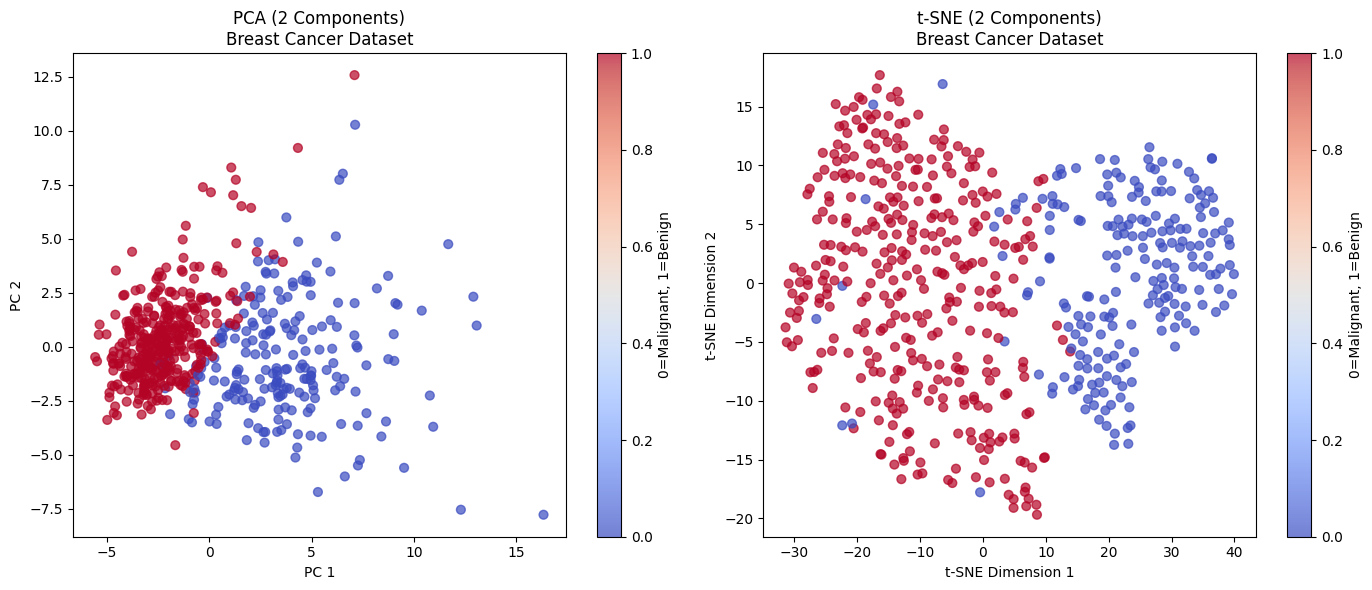

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Load the Breast Cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target  # 0 = malignant, 1 = benign

# 2. Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Run PCA (2 components)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 4. Run t-SNE (2 components)
tsne = TSNE(n_components=2, perplexity=30.0, learning_rate='auto',
            init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 5. Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA Plot
scatter_pca = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7, s=40)
axes[0].set_title('PCA (2 Components)\nBreast Cancer Dataset')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
plt.colorbar(scatter_pca, ax=axes[0], label='0=Malignant, 1=Benign')

# t-SNE Plot
scatter_tsne = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.7, s=40)
axes[1].set_title('t-SNE (2 Components)\nBreast Cancer Dataset')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
plt.colorbar(scatter_tsne, ax=axes[1], label='0=Malignant, 1=Benign')

plt.tight_layout()
plt.show()


### Observation & Comparison

**PCA Result:**
Classes partially separate along PC 1 — malignant (red) cluster left/center, benign (blue) spread right. BUT heavy overlap in middle. No clean boundary. Classes bleed into each other.

**t-SNE Result:**
Two visually distinct blobs — malignant (red) forms dense left cluster, benign (blue) forms separate right cluster. Small overlap zone at boundary but majority cleanly split.

**Which algorithm better separates the classes?**
t-SNE clearly wins. Classes form distinct, spatially separated regions vs PCA's overlapping smear.

**Why?**
PCA = linear projection. Finds directions of max variance, not max class separation. If class boundary is non-linear/curved in 30D space, PCA's shadow flattens it → overlap.

t-SNE = non-linear manifold method. Preserves local neighborhood structure. Points similar in 30D stay close in 2D regardless of global geometry. So malignant tumors (similar cell measurements) pull tight together, benign pull together → natural separation emerges without ever being told the labels.